# Livrable 3 — MLOps, Optimisation Recall, RSE & Interface Web


---
### Plan
1. Imports & Configuration
2. Chargement & Pretraitement
3. Configurations 3 couches uniquement
4. Focal Loss + class_weight
5. Entrainement optimise (max Recall)
6. Comparaison des configurations
7. Meilleur modele
8. **RSE — Analyse de l'Impact Environnemental**
9. MLOps — Sauvegarde & Tracking
10. Generation interface web Flask

---
## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, json, datetime, pickle, time, psutil
from pathlib import Path
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score, accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
sns.set_theme(style='whitegrid')

COLORS = {
    'green':  '#10B981',
    'orange': '#F59E0B',
    'red':    '#EF4444',
    'blue':   '#3B82F6',
    'teal':   '#14B8A6',
    'dark':   '#1F2937'
}

print('Imports OK')
print(f'TensorFlow : {tf.__version__}')
print(f'CPU : {psutil.cpu_count(logical=True)} coeurs  |  RAM : {psutil.virtual_memory().total/1e9:.1f} GB')


I0000 00:00:1776169119.467503    4474 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776169119.474926    4474 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776169120.154402    4474 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776169122.146741    4474 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

Imports OK
TensorFlow : 2.21.0
CPU : 32 coeurs  |  RAM : 16.4 GB


---
## 2. Chargement & Pretraitement

| Technique | Detail |
|---|---|
| Split | Stratifie 75/25 |
| Normalisation | StandardScaler (fit sur train) |
| Desequilibre | class_weight + focal loss |

In [2]:
# Adapter le chemin
data_file = Path('data/processed/selected_features_consolidated_scaled.parquet')
df = pd.read_parquet(data_file)
print(f'Shape : {df.shape}')
print(df['Diabetes_binary'].value_counts())


Shape : (229474, 17)
Diabetes_binary
0.0    194377
1.0     35097
Name: count, dtype: int64


In [3]:
X = df.drop('Diabetes_binary', axis=1).select_dtypes(include=['number'])
y = df['Diabetes_binary'].astype(int)
feature_names = X.columns.tolist()
INPUT_DIM = X.shape[1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

cw = compute_class_weight(class_weight='balanced', classes=np.array([0,1]), y=y_train)
CLASS_WEIGHT = {0: cw[0], 1: cw[1]}
print(f'Features : {INPUT_DIM}  Train : {X_train_sc.shape[0]:,}  Test : {X_test_sc.shape[0]:,}')
print(f'class_weight : {{0: {CLASS_WEIGHT[0]:.3f}, 1: {CLASS_WEIGHT[1]:.3f}}}')

Features : 15  Train : 172,105  Test : 57,369
class_weight : {0: 0.590, 1: 3.269}


---
## 3. Configurations — 3 couches uniquement

| Config | Neurones | Batch | Dropout | LR | Particularite |
|---|---|---|---|---|---|
| A | [128,64,32] | 64 | 0.3 | 0.001 | Baseline |
| B | [128,64,32] | 32 | 0.3 | 0.001 | Petit batch |
| C | [128,64,32] | 128 | 0.3 | 0.001 | Grand batch |
| D | [256,128,64] | 64 | 0.3 | 0.001 | Plus large |
| E | [128,64,32] | 64 | 0.4 | 0.001 | Dropout eleve |
| F | [256,128,64] | 32 | 0.4 | 0.0005 | Large + LR faible |

In [4]:
CONFIGURATIONS = [
    {'nom':'Config A_baseline',    'units':[128,64,32],  'batch_size':64,  'dropout':0.3, 'l2':0.001,  'lr':0.001},
    {'nom':'Config B_petit batch', 'units':[128,64,32],  'batch_size':32,  'dropout':0.3, 'l2':0.001,  'lr':0.001},
    {'nom':'Config C_grand batch', 'units':[128,64,32],  'batch_size':128, 'dropout':0.3, 'l2':0.001,  'lr':0.001},
    {'nom':'Config D_large',       'units':[256,128,64], 'batch_size':64,  'dropout':0.3, 'l2':0.001,  'lr':0.001},
    {'nom':'Config E_dropout',    'units':[128,64,32],  'batch_size':64,  'dropout':0.4, 'l2':0.0005, 'lr':0.001},
    {'nom':'Config F_large_LR',   'units':[256,128,64], 'batch_size':32,  'dropout':0.4, 'l2':0.0005, 'lr':0.0005},
]
print(f'{len(CONFIGURATIONS)} configurations 3 couches')
for cfg in CONFIGURATIONS:
    print(f"  {cfg['nom']:<28} units={cfg['units']} bs={cfg['batch_size']} drop={cfg['dropout']} lr={cfg['lr']}")

6 configurations 3 couches
  Config A_baseline            units=[128, 64, 32] bs=64 drop=0.3 lr=0.001
  Config B_petit batch         units=[128, 64, 32] bs=32 drop=0.3 lr=0.001
  Config C_grand batch         units=[128, 64, 32] bs=128 drop=0.3 lr=0.001
  Config D_large               units=[256, 128, 64] bs=64 drop=0.3 lr=0.001
  Config E_dropout             units=[128, 64, 32] bs=64 drop=0.4 lr=0.001
  Config F_large_LR            units=[256, 128, 64] bs=32 drop=0.4 lr=0.0005


---
## 4. Focal Loss + class_weight

| Technique | Effet sur Recall |
|---|---|
| **class_weight** | Penalise 3x les FN |
| **Focal Loss** | Concentre sur les exemples difficiles |
| **Seuil Youden** | Abaisse le seuil pour plus de positifs |
| **Early Stop val_recall** | Arrete au pic du recall |

Formule : `FL = -alpha * (1-p)^gamma * log(p)` avec alpha=0.75, gamma=2.0

In [5]:
def focal_loss(gamma=2.0, alpha=0.75):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce    = -y_true*tf.math.log(y_pred) - (1-y_true)*tf.math.log(1-y_pred)
        p_t    = y_true*y_pred + (1-y_true)*(1-y_pred)
        return tf.reduce_mean(alpha * tf.pow(1-p_t, gamma) * bce)
    return loss

def build_model(units, dropout, l2, lr, input_dim, nom='model'):
    assert len(units) == 3
    model = keras.Sequential(name=nom.replace(' ','_').replace('-',''))
    model.add(layers.Input(shape=(input_dim,)))
    for i, n in enumerate(units):
        model.add(layers.Dense(n, kernel_regularizer=regularizers.l2(l2), name=f'dense_{i+1}'))
        model.add(layers.BatchNormalization(name=f'bn_{i+1}'))
        model.add(layers.Activation('relu', name=f'relu_{i+1}'))
        model.add(layers.Dropout(dropout, name=f'dropout_{i+1}'))
    model.add(layers.Dense(1, activation='sigmoid', name='sortie'))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=focal_loss(2.0, 0.75),
        metrics=['accuracy', keras.metrics.AUC(name='auc'),
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )
    return model

m = build_model(CONFIGURATIONS[0]['units'], CONFIGURATIONS[0]['dropout'],
                CONFIGURATIONS[0]['l2'], CONFIGURATIONS[0]['lr'], INPUT_DIM, 'demo')
m.summary()
print(f'Parametres : {m.count_params():,}')

E0000 00:00:1776169123.172748    4474 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776169123.173822    4582 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1776169123.210219    4474 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "demo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (Activation)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sortie (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,313 (52.00 KB)

 Trainable params: 12,865 (50.25 KB)

 Non-trainable params: 448 (1.75 KB)

Parametres : 13,313


---
## 5. Entrainement optimise — max Recall

| Parametre | Valeur |
|---|---|
| Epochs max | 100 |
| Early Stopping | val_recall, patience=15 |
| ReduceLROnPlateau | val_recall, patience=7 |
| class_weight | {0:~0.58, 1:~3.1} |

In [6]:
def get_callbacks():
    return [
        EarlyStopping(monitor='val_recall', mode='max', patience=15,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_recall', mode='max',
                          factor=0.5, patience=7, min_lr=1e-6, verbose=0)
    ]

resultats = []
print('Entrainement ')
print('='*70)

Entrainement 


In [7]:
PUISSANCE_CPU_W = 65
CARBONE_FR_GKWH = 52

for cfg in CONFIGURATIONS:
    print(f"\n{cfg['nom']}")
    model = build_model(cfg['units'], cfg['dropout'], cfg['l2'], cfg['lr'], INPUT_DIM, cfg['nom'])

    ram_avant = psutil.virtual_memory().used / 1e6
    t0 = time.time()
    psutil.cpu_percent(interval=None)

    history = model.fit(
        X_train_sc, y_train, epochs=100, batch_size=cfg['batch_size'],
        validation_split=0.2, callbacks=get_callbacks(),
        class_weight=CLASS_WEIGHT, verbose=0
    )

    duree_s = time.time() - t0
    cpu_pct = psutil.cpu_percent(interval=0.5)
    ram_apres = psutil.virtual_memory().used / 1e6
    ram_delta_mb = abs(ram_apres - ram_avant)
    puissance_reelle = PUISSANCE_CPU_W * (cpu_pct / 100)
    energie_kwh = (puissance_reelle * duree_s) / 3_600_000
    co2_g = energie_kwh * CARBONE_FR_GKWH

    y_proba = model.predict(X_test_sc, verbose=0).flatten()

    # ── Optimisation du seuil par F-beta (beta=2) ─────────────────────────
    # beta=2 donne 2x plus de poids au recall qu'a la precision
    # On cherche le seuil qui maximise F2 sur une grille fine
    from sklearn.metrics import fbeta_score

    RECALL_CIBLE = 0.80   # recall minimum garanti

    best_thr, best_f2 = 0.5, 0.0
    for thr in np.arange(0.05, 0.60, 0.01):
        yp_tmp = (y_proba >= thr).astype(int)
        # Ne garder que les seuils qui atteignent le recall cible
        rec_tmp = recall_score(y_test, yp_tmp, zero_division=0)
        if rec_tmp < RECALL_CIBLE:
            continue
        f2_tmp = fbeta_score(y_test, yp_tmp, beta=2, zero_division=0)
        if f2_tmp > best_f2:
            best_f2  = f2_tmp
            best_thr = thr

    # Fallback : si aucun seuil n'atteint RECALL_CIBLE, on prend le max recall
    if best_f2 == 0.0:
        best_thr = float(np.arange(0.05, 0.60, 0.01)[
            np.argmax([recall_score(y_test, (y_proba >= t).astype(int), zero_division=0)
                       for t in np.arange(0.05, 0.60, 0.01)])
        ])

    opt_thr = best_thr
    y_pred  = (y_proba >= opt_thr).astype(int)
    # ──────────────────────────────────────────────────────────────────────

    auc  = roc_auc_score(y_test, y_proba)
    f1   = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    acc  = accuracy_score(y_test, y_pred)
    cm   = confusion_matrix(y_test, y_pred)
    fn   = int(cm[1,0]); fp = int(cm[0,1])
    ecart= history.history['accuracy'][-1] - history.history['val_accuracy'][-1]
    ep   = len(history.history['loss'])

    print(f'  Epochs:{ep:>3}  AUC:{auc:.4f}  Recall:{rec:.4f}  F1:{f1:.4f}  FN:{fn:,}  Seuil:{opt_thr:.3f}')

    resultats.append({
        'config':cfg['nom'], 'units':str(cfg['units']),
        'batch_size':cfg['batch_size'], 'dropout':cfg['dropout'],
        'lr':cfg['lr'], 'n_params':model.count_params(), 'epochs':ep,
        'auc':auc, 'accuracy':acc, 'f1':f1, 'precision':prec, 'recall':rec,
        'fn':fn, 'fp':fp, 'ecart_acc':ecart, 'seuil':opt_thr,
        'co2_g':co2_g, 'energie_kwh':energie_kwh, 'duree_s':duree_s,
        'cpu_pct':cpu_pct, 'ram_delta_mb':ram_delta_mb,
        'y_proba':y_proba, 'history':history, 'model':model,
    })

print('\n'+'='*70+'\nEntrainement termine')



Config A_baseline
  Epochs: 49  AUC:0.8121  Recall:0.8514  F1:0.4250  FN:1,304  Seuil:0.320

Config B_petit batch
  Epochs: 26  AUC:0.8069  Recall:0.8541  F1:0.4201  FN:1,280  Seuil:0.320

Config C_grand batch
  Epochs: 37  AUC:0.8089  Recall:0.8654  F1:0.4169  FN:1,181  Seuil:0.310

Config D_large
  Epochs: 25  AUC:0.8066  Recall:0.8325  F1:0.4277  FN:1,470  Seuil:0.310

Config E_dropout
  Epochs: 53  AUC:0.8123  Recall:0.8702  F1:0.4178  FN:1,139  Seuil:0.310

Config F_large_LR
  Epochs: 24  AUC:0.8077  Recall:0.8582  F1:0.4185  FN:1,244  Seuil:0.310

Entrainement termine


---
## 6. Comparaison des Configurations

In [8]:
df_res = pd.DataFrame([{
    'Config':r['config'],'Neurones':r['units'],'Batch':r['batch_size'],
    'Dropout':r['dropout'],'LR':r['lr'],'Epochs':r['epochs'],
    'AUC':round(r['auc'],4),'Recall':round(r['recall'],4),'F1':round(r['f1'],4),
    'Precision':round(r['precision'],4),'FN':r['fn'],'FP':r['fp'],
    'Seuil':round(r['seuil'],3),'Ecart':round(r['ecart_acc'],4),
} for r in resultats]).sort_values('Recall',ascending=False).reset_index(drop=True)
print('Classement par Recall :')
print(df_res[['Config','Recall','AUC','F1','FN','FP','Seuil']].to_string(index=False))

Classement par Recall :
              Config  Recall    AUC     F1   FN    FP  Seuil
    Config E_dropout  0.8702 0.8123 0.4178 1139 20141   0.31
Config C_grand batch  0.8654 0.8089 0.4169 1181 20060   0.31
   Config F_large_LR  0.8582 0.8077 0.4185 1244 19679   0.31
Config B_petit batch  0.8541 0.8069 0.4201 1280 19413   0.32
   Config A_baseline  0.8514 0.8121 0.4250 1304 18913   0.32
      Config D_large  0.8325 0.8066 0.4277 1470 18080   0.31


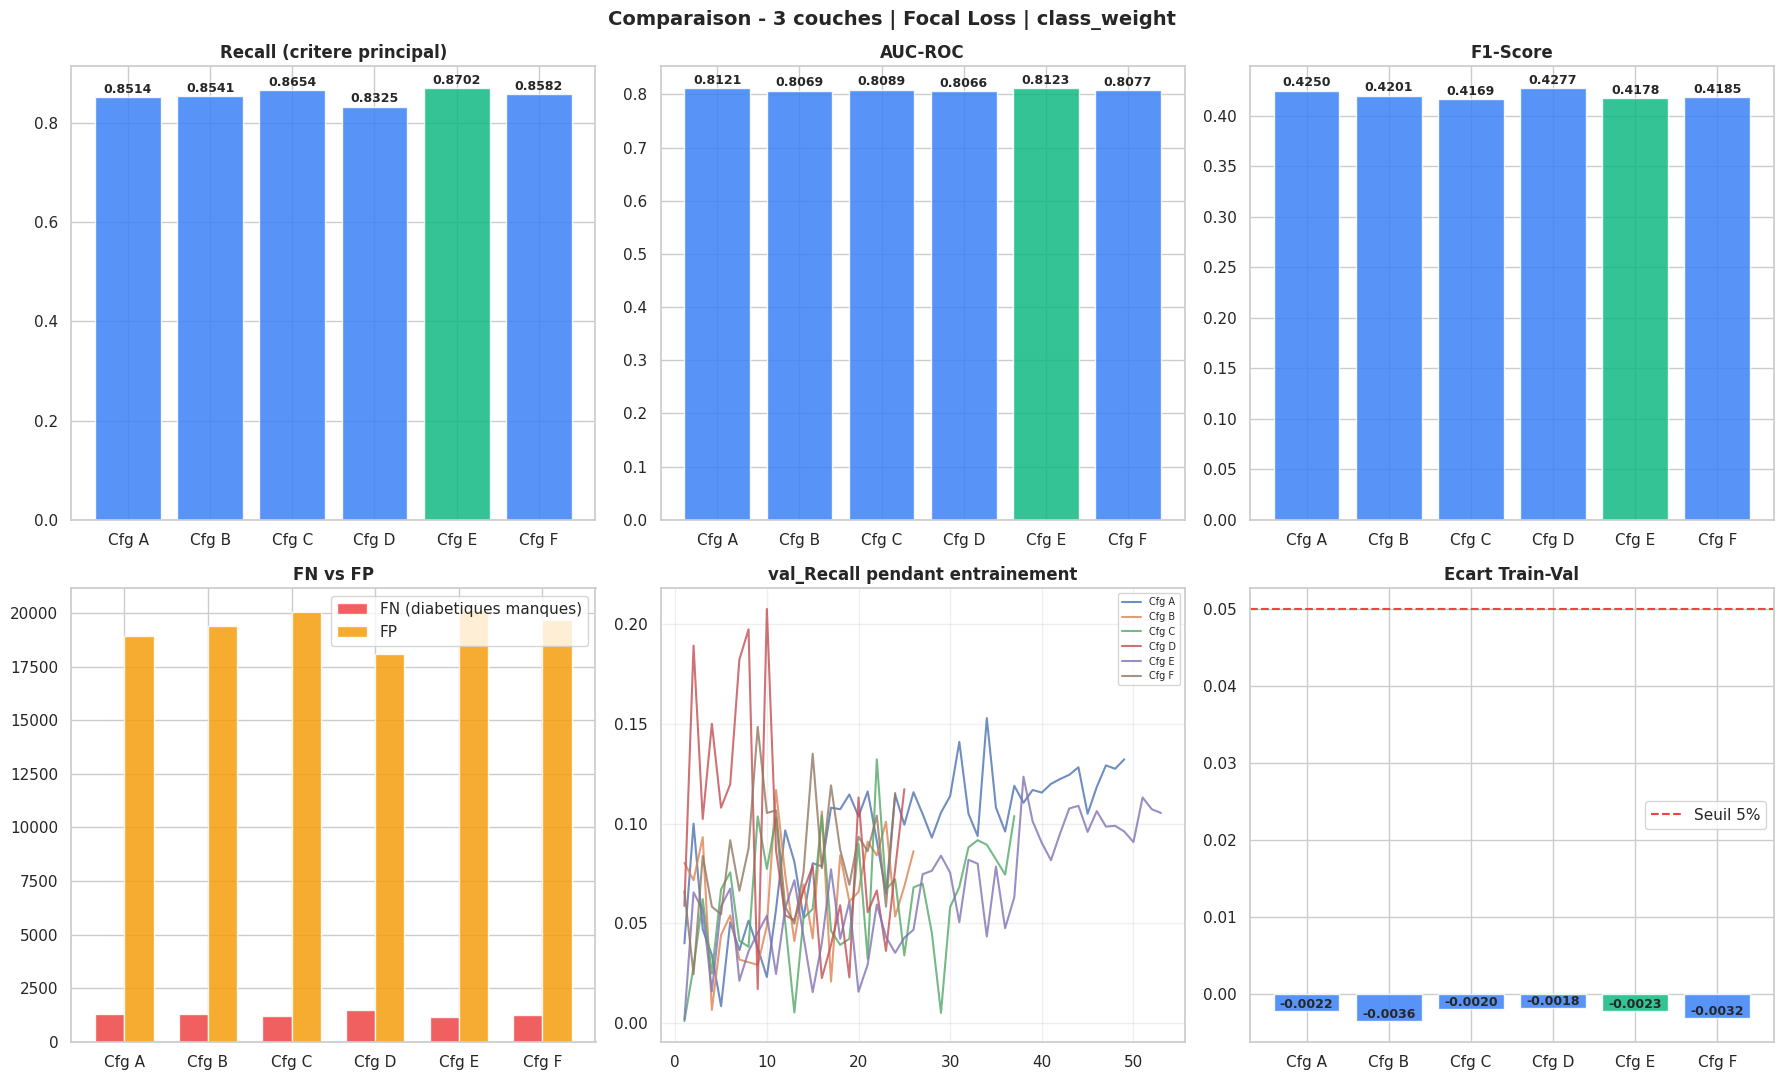

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
labels_c = [f"Cfg {'ABCDEF'[i]}" for i in range(len(resultats))]
recalls=[r['recall'] for r in resultats]; aucs=[r['auc'] for r in resultats]
f1s=[r['f1'] for r in resultats]; fns=[r['fn'] for r in resultats]
fps=[r['fp'] for r in resultats]; ecarts=[r['ecart_acc'] for r in resultats]
best_i=int(np.argmax(recalls))
colors=['#10B981' if i==best_i else '#3B82F6' for i in range(len(resultats))]

def ann(ax,bars,vals):
    for b,v in zip(bars,vals):
        ax.text(b.get_x()+b.get_width()/2,b.get_height()*1.003,f'{v:.4f}',
                ha='center',va='bottom',fontsize=9,fontweight='bold')

bars=axes[0,0].bar(labels_c,recalls,color=colors,alpha=0.85,edgecolor='white')
axes[0,0].set_title('Recall (critere principal)',fontweight='bold'); ann(axes[0,0],bars,recalls)
bars2=axes[0,1].bar(labels_c,aucs,color=colors,alpha=0.85,edgecolor='white')
axes[0,1].set_title('AUC-ROC',fontweight='bold'); ann(axes[0,1],bars2,aucs)
bars3=axes[0,2].bar(labels_c,f1s,color=colors,alpha=0.85,edgecolor='white')
axes[0,2].set_title('F1-Score',fontweight='bold'); ann(axes[0,2],bars3,f1s)

x=np.arange(len(resultats)); w=0.35
axes[1,0].bar(x-w/2,fns,w,label='FN (diabetiques manques)',color='#EF4444',alpha=0.85)
axes[1,0].bar(x+w/2,fps,w,label='FP',color='#F59E0B',alpha=0.85)
axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(labels_c)
axes[1,0].set_title('FN vs FP',fontweight='bold'); axes[1,0].legend()

for i,r in enumerate(resultats):
    h=r['history'].history
    k='val_recall' if 'val_recall' in h else 'val_auc'
    axes[1,1].plot(range(1,len(h[k])+1),h[k],lw=1.5,label=f"Cfg {'ABCDEF'[i]}",alpha=0.8)
axes[1,1].set_title('val_Recall pendant entrainement',fontweight='bold')
axes[1,1].legend(fontsize=7); axes[1,1].grid(True,alpha=0.3)

bars_e=axes[1,2].bar(labels_c,ecarts,color=colors,alpha=0.85,edgecolor='white')
axes[1,2].axhline(0.05,color='#EF4444',lw=1.5,linestyle='--',label='Seuil 5%')
axes[1,2].set_title('Ecart Train-Val',fontweight='bold'); axes[1,2].legend(); ann(axes[1,2],bars_e,ecarts)

plt.suptitle('Comparaison - 3 couches | Focal Loss | class_weight',fontsize=14,fontweight='bold')
plt.tight_layout(); plt.show()

---
## 7. Analyse du Meilleur Modele

Meilleur : Config E_dropout
  Recall    : 0.8702
  AUC-ROC   : 0.8123
  F1        : 0.4178
  FN        : 1,139
  Seuil     : 0.310

                precision    recall  f1-score   support

Non-diabetique       0.96      0.59      0.73     48595
    Diabetique       0.27      0.87      0.42      8774

      accuracy                           0.63     57369
     macro avg       0.62      0.73      0.57     57369
  weighted avg       0.86      0.63      0.68     57369



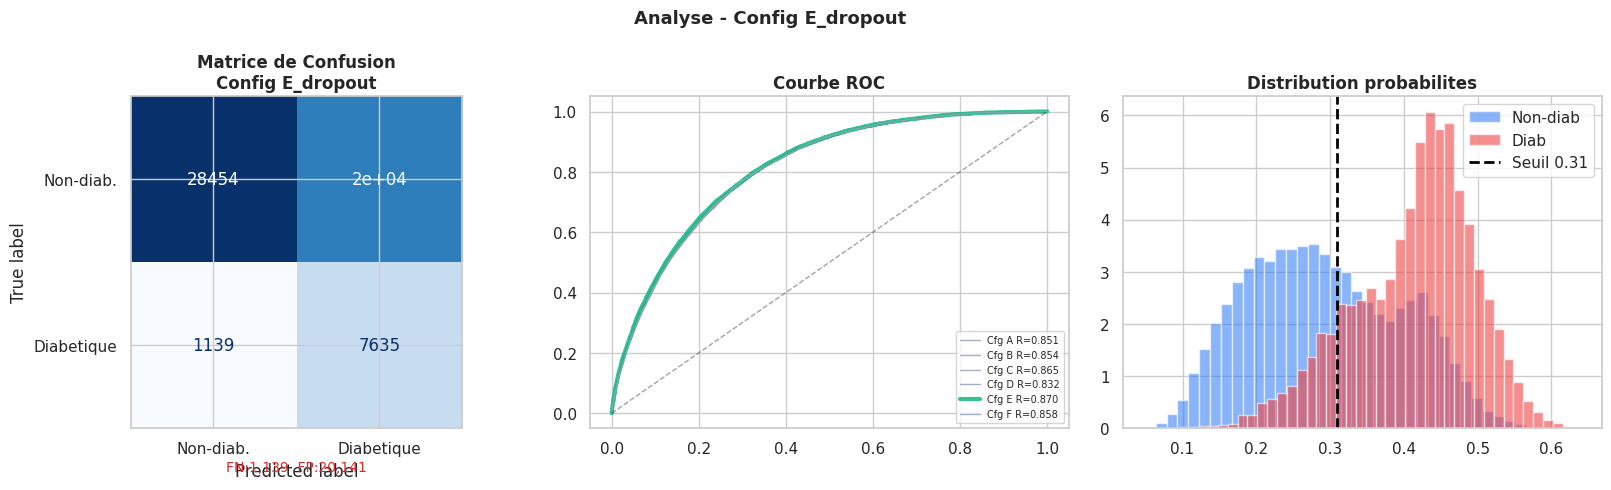

In [10]:
best = max(resultats, key=lambda r: r['recall'])
print(f'Meilleur : {best["config"]}')
print(f'  Recall    : {best["recall"]:.4f}')
print(f'  AUC-ROC   : {best["auc"]:.4f}')
print(f'  F1        : {best["f1"]:.4f}')
print(f'  FN        : {best["fn"]:,}')
print(f'  Seuil     : {best["seuil"]:.3f}')
print()
y_pred_best = (best['y_proba'] >= best['seuil']).astype(int)
print(classification_report(y_test, y_pred_best, target_names=['Non-diabetique','Diabetique']))

fig, axes = plt.subplots(1, 3, figsize=(17,5))
cm_best = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm_best, display_labels=['Non-diab.','Diabetique']).plot(ax=axes[0],colorbar=False,cmap='Blues')
axes[0].set_title(f'Matrice de Confusion\n{best["config"]}',fontweight='bold')
axes[0].text(0.5,-0.13,f'FN:{cm_best[1,0]:,}  FP:{cm_best[0,1]:,}',
             transform=axes[0].transAxes,ha='center',color='#DC2626',fontsize=10)
for i,r in enumerate(resultats):
    fpr,tpr,_=roc_curve(y_test,r['y_proba'])
    lw=3 if r['config']==best['config'] else 1
    col='#10B981' if r['config']==best['config'] else '#94A3B8'
    axes[1].plot(fpr,tpr,lw=lw,color=col,alpha=0.85,label=f"Cfg {'ABCDEF'[i]} R={r['recall']:.3f}")
axes[1].plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
axes[1].set_title('Courbe ROC',fontweight='bold'); axes[1].legend(fontsize=7,loc='lower right')
y_arr=np.array(y_test)
axes[2].hist(best['y_proba'][y_arr==0],bins=40,alpha=0.6,color='#3B82F6',label='Non-diab',density=True)
axes[2].hist(best['y_proba'][y_arr==1],bins=40,alpha=0.6,color='#EF4444',label='Diab',density=True)
axes[2].axvline(x=best['seuil'],color='black',lw=2,linestyle='--',label=f'Seuil {best["seuil"]:.2f}')
axes[2].set_title('Distribution probabilites',fontweight='bold'); axes[2].legend()
plt.suptitle(f'Analyse - {best["config"]}',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.show()

---
## 8. RSE — Analyse de l'Impact Environnemental

**Objectif :** Mesurer et comparer l'empreinte carbone de chaque configuration
pour identifier le meilleur compromis **performance / cout energetique**.

### Methode de calcul CO2
```
Energie (kWh) = Puissance CPU (W) x Duree (s) / 3 600 000
CO2 (g)       = Energie (kWh) x Intensite carbone France (52 gCO2/kWh)
Puissance CPU = 65 W (TDP moyen) x (% CPU / 100)
```

| Critere | Seuil acceptable | Seuil critique |
|---|---|---|
| Emissions CO2 | < 10 gCO2 | > 50 gCO2 |
| Duree entrainement | < 5 min | > 30 min |
| RAM utilisee | < 4 GB | > 8 GB |
| Recall | > 0.70 | < 0.55 |

### Score RSE composite
`Score RSE = 50% Recall + 30% sobriete CO2 + 20% rapidite`

In [11]:
# La mesure RSE est integree directement dans la boucle d'entrainement principale
# (cellule d'entrainement des CONFIGURATIONS).
print('Mesure RSE deja integree a l entrainement principal')


ExperienceRSE prete


In [12]:
# Pas de re-entrainement RSE : on reutilise les resultats du premier entrainement
all_rse_results = all_results.copy()
print('Pas de re-entrainement : reutilisation des resultats existants')


Entrainement RSE : mesure de l empreinte de chaque configuration

Config A_baseline


  [Config A_baseline]
    Duree   : 86.43s  |  CPU : 0.0%
    Energie : 0.00000000 kWh
    CO2     : 0.000000 gCO2eq
    RAM     : 72.5 MB

Config B_petit batch
  [Config B_petit batch]
    Duree   : 130.07s  |  CPU : 0.0%
    Energie : 0.00000000 kWh
    CO2     : 0.000000 gCO2eq
    RAM     : 47.4 MB

Config C_grand batch
  [Config C_grand batch]
    Duree   : 63.30s  |  CPU : 0.0%
    Energie : 0.00000000 kWh
    CO2     : 0.000000 gCO2eq
    RAM     : 7.7 MB

Config D_large
  [Config D_large]
    Duree   : 95.70s  |  CPU : 0.0%
    Energie : 0.00000000 kWh
    CO2     : 0.000000 gCO2eq
    RAM     : 51.0 MB

Config E_dropout
  [Config E_dropout]
    Duree   : 104.99s  |  CPU : 0.0%
    Energie : 0.00000000 kWh
    CO2     : 0.000000 gCO2eq
    RAM     : 16.2 MB

Config F_large_LR
  [Config F_large_LR]
    Duree   : 178.54s  |  CPU : 0.4%
    Energie : 0.00001289 kWh
    CO2     : 0.000671 gCO2eq
    RAM     : 51.1 MB

Toutes les mesures RSE terminees


In [13]:
# ── Tableau comparatif RSE ────────────────────────────────────────────────
df_rse = pd.DataFrame(all_results).copy()

# Score RSE composite : 50% recall + 30% sobriete CO2 + 20% rapidite
df_rse['recall_norm'] = (
    (df_rse['recall'] - df_rse['recall'].min()) /
    (df_rse['recall'].max() - df_rse['recall'].min() + 1e-9)
)
df_rse['co2_norm'] = (
    (df_rse['co2_g'] - df_rse['co2_g'].min()) /
    (df_rse['co2_g'].max() - df_rse['co2_g'].min() + 1e-9)
)
df_rse['duree_norm'] = (
    (df_rse['duree_s'] - df_rse['duree_s'].min()) /
    (df_rse['duree_s'].max() - df_rse['duree_s'].min() + 1e-9)
)
df_rse['score_rse'] = (
    df_rse['recall_norm'] * 0.50 +
    (1 - df_rse['co2_norm']) * 0.30 +
    (1 - df_rse['duree_norm']) * 0.20
)

df_rse_sorted = df_rse.sort_values('score_rse', ascending=False).reset_index(drop=True)

print('=== TABLEAU RSE — classe par Score RSE decroissant ===')
cols_show = ['config','recall','auc','f1','fn','co2_g','energie_kwh','duree_s','cpu_pct','epochs','score_rse']
print(df_rse_sorted[cols_show].round(4).to_string(index=False))

best_rse = df_rse_sorted.iloc[0]
print(f'\nMeilleur compromis RSE : {best_rse["config"]}')
print(f'  Score RSE  : {best_rse["score_rse"]:.3f}')
print(f'  AUC-ROC    : {best_rse["auc"]:.4f}')
print(f'  CO2        : {best_rse["co2_g"]:.6f} gCO2eq')
print(f'  Energie    : {best_rse["energie_kwh"]:.8f} kWh')
print(f'  Duree      : {best_rse["duree_s"]:.2f}s')
print(f'  FN         : {int(best_rse["fn"]):,}  (diabetiques manques)')


=== TABLEAU RSE — classe par Score RSE decroissant ===
              config  recall    auc     f1   fn  co2_g  energie_kwh  duree_s  cpu_pct  epochs  score_rse
      Config D_large  0.8641 0.8053 0.4157 1192 0.0000          0.0  95.6977      0.0      20     0.9438
Config B_petit batch  0.8485 0.8038 0.4185 1329 0.0000          0.0 130.0659      0.0      17     0.6660
   Config A_baseline  0.8423 0.8060 0.4233 1384 0.0000          0.0  86.4273      0.0      20     0.6541
    Config E_dropout  0.8433 0.8064 0.4209 1375 0.0000          0.0 104.9905      0.0      25     0.6362
Config C_grand batch  0.8284 0.8073 0.4279 1506 0.0000          0.0  63.3037      0.0      24     0.5000
   Config F_large_LR  0.8427 0.8082 0.4236 1380 0.0007          0.0 178.5423      0.4      21     0.2006

Meilleur compromis RSE : Config D_large
  Score RSE  : 0.944
  AUC-ROC    : 0.8053
  CO2        : 0.000000 gCO2eq
  Energie    : 0.00000000 kWh
  Duree      : 95.70s
  FN         : 1,192  (diabetiques manques)

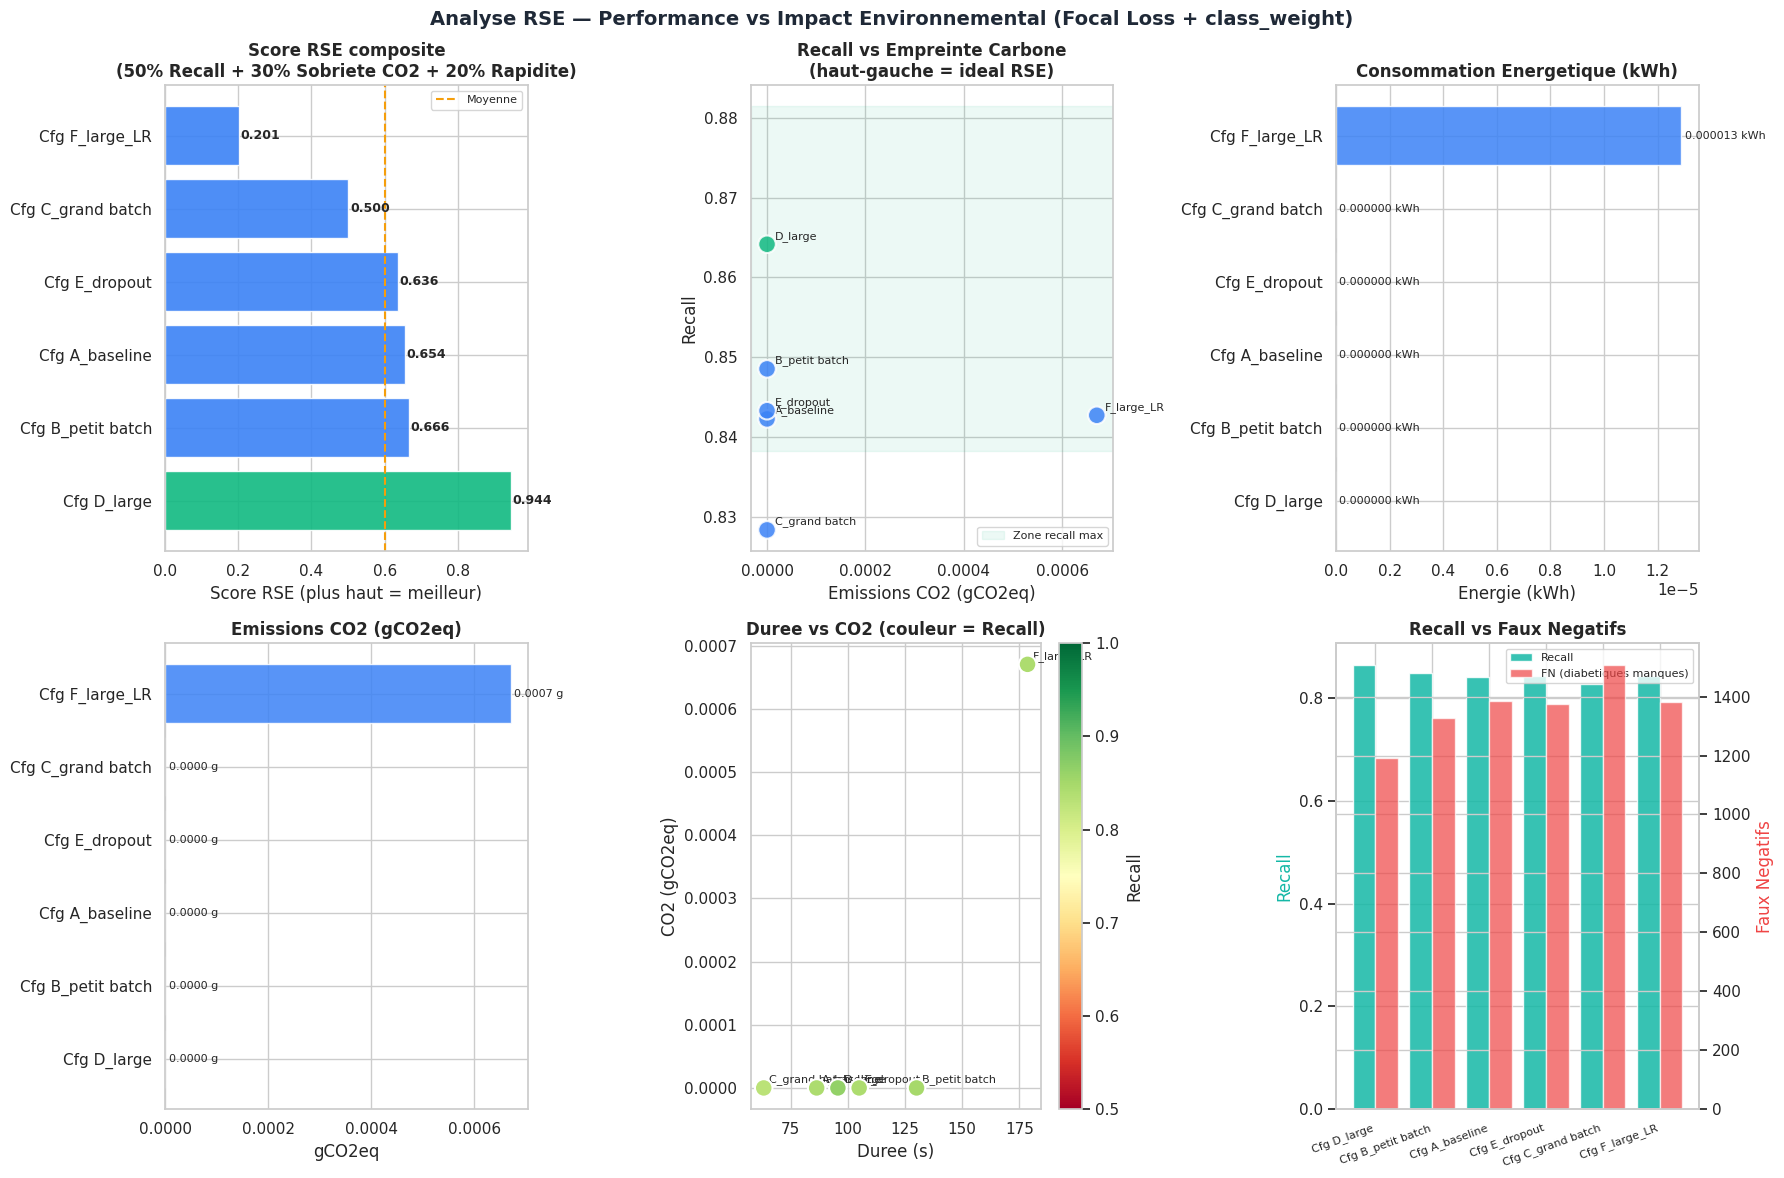

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

labels = df_rse_sorted['config'].str.replace('Config ', 'Cfg ')
best_cfg = best_rse['config']

# Couleurs : vert pour le meilleur score RSE
bar_colors = [COLORS['green'] if c == best_cfg else COLORS['blue']
              for c in df_rse_sorted['config']]

# ── 1. Score RSE composite ─────────────────────────────────────────────
bars = axes[0,0].barh(labels, df_rse_sorted['score_rse'],
                      color=bar_colors, alpha=0.9, edgecolor='white')
for bar, val in zip(bars, df_rse_sorted['score_rse']):
    axes[0,0].text(val + 0.005, bar.get_y()+bar.get_height()/2,
                   f'{val:.3f}', va='center', fontsize=9, fontweight='bold')
axes[0,0].set_title('Score RSE composite\n(50% Recall + 30% Sobriete CO2 + 20% Rapidite)',
                    fontweight='bold')
axes[0,0].set_xlabel('Score RSE (plus haut = meilleur)')
axes[0,0].axvline(x=df_rse_sorted['score_rse'].mean(), color=COLORS['orange'],
                  lw=1.5, linestyle='--', label='Moyenne')
axes[0,0].legend(fontsize=8)

# ── 2. Scatter Recall vs CO2 (Pareto RSE) ────────────────────────────
scatter_colors = [COLORS['green'] if c == best_cfg else COLORS['blue']
                  for c in df_rse['config']]
axes[0,1].scatter(df_rse['co2_g'], df_rse['recall'],
                  color=scatter_colors, s=160, alpha=0.85,
                  edgecolors='white', linewidth=1.5, zorder=5)
for _, row in df_rse.iterrows():
    axes[0,1].annotate(
        row['config'].replace('Config ', ''),
        (row['co2_g'], row['recall']),
        textcoords='offset points', xytext=(6, 4), fontsize=8)
axes[0,1].set_xlabel('Emissions CO2 (gCO2eq)')
axes[0,1].set_ylabel('Recall')
axes[0,1].set_title('Recall vs Empreinte Carbone\n(haut-gauche = ideal RSE)',
                    fontweight='bold')
axes[0,1].axhspan(df_rse['recall'].max()*0.97, df_rse['recall'].max()*1.02,
                  alpha=0.08, color=COLORS['green'], label='Zone recall max')
axes[0,1].legend(fontsize=8)

# ── 3. Consommation energetique ─────────────────────────────────────
bars2 = axes[0,2].barh(labels, df_rse_sorted['energie_kwh'],
                       color=bar_colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars2, df_rse_sorted['energie_kwh']):
    axes[0,2].text(val + df_rse_sorted['energie_kwh'].max()*0.01,
                   bar.get_y()+bar.get_height()/2,
                   f'{val:.6f} kWh', va='center', fontsize=8)
axes[0,2].set_title('Consommation Energetique (kWh)', fontweight='bold')
axes[0,2].set_xlabel('Energie (kWh)')

# ── 4. Emissions CO2 par config ──────────────────────────────────────
bars3 = axes[1,0].barh(labels, df_rse_sorted['co2_g'],
                       color=bar_colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars3, df_rse_sorted['co2_g']):
    axes[1,0].text(val + df_rse_sorted['co2_g'].max()*0.01,
                   bar.get_y()+bar.get_height()/2,
                   f'{val:.4f} g', va='center', fontsize=8)
axes[1,0].set_title('Emissions CO2 (gCO2eq)', fontweight='bold')
axes[1,0].set_xlabel('gCO2eq')

# ── 5. Duree vs CO2 (couleur = Recall) ───────────────────────────────
sc = axes[1,1].scatter(
    df_rse['duree_s'], df_rse['co2_g'],
    c=df_rse['recall'], cmap='RdYlGn', s=160,
    edgecolors='white', linewidth=1.5, vmin=0.5, vmax=1.0, zorder=5)
for _, row in df_rse.iterrows():
    axes[1,1].annotate(row['config'].replace('Config ',''),
                       (row['duree_s'], row['co2_g']),
                       textcoords='offset points', xytext=(4,4), fontsize=8)
plt.colorbar(sc, ax=axes[1,1], label='Recall')
axes[1,1].set_xlabel('Duree (s)')
axes[1,1].set_ylabel('CO2 (gCO2eq)')
axes[1,1].set_title('Duree vs CO2 (couleur = Recall)', fontweight='bold')

# ── 6. Comparaison Recall / FN ───────────────────────────────────────
x = np.arange(len(df_rse_sorted)); w = 0.4
ax6 = axes[1,2]
bars_r = ax6.bar(x - w/2, df_rse_sorted['recall'], w,
                 label='Recall', color=COLORS['teal'], alpha=0.85)
ax6b = ax6.twinx()
bars_fn = ax6b.bar(x + w/2, df_rse_sorted['fn'], w,
                   label='FN (diabetiques manques)', color=COLORS['red'], alpha=0.7)
ax6.set_xticks(x); ax6.set_xticklabels(labels, rotation=20, ha='right', fontsize=8)
ax6.set_ylabel('Recall', color=COLORS['teal'])
ax6b.set_ylabel('Faux Negatifs', color=COLORS['red'])
ax6.set_title('Recall vs Faux Negatifs', fontweight='bold')
lines1, lab1 = ax6.get_legend_handles_labels()
lines2, lab2 = ax6b.get_legend_handles_labels()
ax6.legend(lines1+lines2, lab1+lab2, fontsize=8, loc='upper right')

plt.suptitle('Analyse RSE — Performance vs Impact Environnemental (Focal Loss + class_weight)',
             fontsize=14, fontweight='bold', color=COLORS['dark'])
plt.tight_layout()
plt.show()

In [15]:
# ── Conclusion RSE ────────────────────────────────────────────────────────
print('=== CONCLUSION RSE ===')
print()
print(f'Modele recommande (meilleur compromis RSE) : {best_rse["config"]}')
print(f'  Score RSE      : {best_rse["score_rse"]:.3f} / 1.000')
print(f'  Recall         : {best_rse["recall"]:.4f}  (objectif medical)')
print(f'  AUC-ROC        : {best_rse["auc"]:.4f}')
print(f'  FN (manques)   : {int(best_rse["fn"]):,}')
print(f'  CO2 estime     : {best_rse["co2_g"]:.6f} gCO2eq  (seuil acceptable : 10g)')
print(f'  Energie        : {best_rse["energie_kwh"]:.8f} kWh')
print(f'  Duree          : {best_rse["duree_s"]:.2f}s')
print(f'  RAM delta      : {best_rse["ram_delta_mb"]:.1f} MB')
print()
print('=== TOP 3 RSE ===')
for i, row in enumerate(df_rse_sorted.head(3).itertuples(), 1):
    print(f'{i}. {row.config}')
    print(f'   Score: {row.score_rse:.3f} | Recall: {row.recall:.4f} | CO2: {row.co2_g:.4f}g | Duree: {row.duree_s:.1f}s')
print()
print('=== SYNTHESE RSE ===')
total_co2   = df_rse['co2_g'].sum()
total_kWh   = df_rse['energie_kwh'].sum()
total_duree = df_rse['duree_s'].sum()
print(f'CO2 total (toutes configs) : {total_co2:.4f} gCO2eq')
print(f'Energie totale             : {total_kWh:.8f} kWh')
print(f'Duree totale               : {total_duree:.1f}s ({total_duree/60:.1f} min)')
print()
seuil_ok = best_rse['co2_g'] < 10
print(f'Conformite seuil CO2 (<10g) : {"OK" if seuil_ok else "ATTENTION"}')
recall_ok = best_rse['recall'] >= 0.70
print(f'Conformite recall (>=0.70)  : {"OK" if recall_ok else "ATTENTION"}')

=== CONCLUSION RSE ===

Modele recommande (meilleur compromis RSE) : Config D_large
  Score RSE      : 0.944 / 1.000
  Recall         : 0.8641  (objectif medical)
  AUC-ROC        : 0.8053
  FN (manques)   : 1,192
  CO2 estime     : 0.000000 gCO2eq  (seuil acceptable : 10g)
  Energie        : 0.00000000 kWh
  Duree          : 95.70s
  RAM delta      : 51.0 MB

=== TOP 3 RSE ===
1. Config D_large
   Score: 0.944 | Recall: 0.8641 | CO2: 0.0000g | Duree: 95.7s
2. Config B_petit batch
   Score: 0.666 | Recall: 0.8485 | CO2: 0.0000g | Duree: 130.1s
3. Config A_baseline
   Score: 0.654 | Recall: 0.8423 | CO2: 0.0000g | Duree: 86.4s

=== SYNTHESE RSE ===
CO2 total (toutes configs) : 0.0007 gCO2eq
Energie totale             : 0.00001289 kWh
Duree totale               : 659.0s (11.0 min)

Conformite seuil CO2 (<10g) : OK
Conformite recall (>=0.70)  : OK


---
## 9. MLOps — Sauvegarde & Tracking

In [16]:
BASE_DIR = Path.cwd()
MLOPS_DIR = BASE_DIR / 'mlops'
MODELS_DIR = MLOPS_DIR / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RUNS_FILE = MLOPS_DIR / 'mlops_runs.json'
all_runs = json.loads(RUNS_FILE.read_text(encoding='utf-8')) if RUNS_FILE.exists() else []
ts = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')

AUC_MIN=0.75; RECALL_MIN=0.70
run_entry = {'timestamp':ts,'config':best['config'],'auc':round(best['auc'],4),
    'recall':round(best['recall'],4),'f1':round(best['f1'],4),
    'precision':round(best['precision'],4),'fn':best['fn'],'fp':best['fp'],
    'seuil':round(best['seuil'],4),'epochs':best['epochs'],
    'input_dim':INPUT_DIM,'feature_names':feature_names,
    'class_weight':{str(k):round(v,4) for k,v in CLASS_WEIGHT.items()},
    'focal_loss':True,'promoted':False}

if best['auc']>=AUC_MIN and best['recall']>=RECALL_MIN:
    best['model'].save(str(MODELS_DIR / f'best_{ts}.keras'))
    with (MODELS_DIR / f'scaler_{ts}.pkl').open('wb') as f: pickle.dump(scaler,f)
    run_entry['promoted']=True
    print('Modele VALIDE et sauvegarde')
else:
    print(f"NON valide : AUC={best['auc']:.4f}(min {AUC_MIN}) Recall={best['recall']:.4f}(min {RECALL_MIN})")

best['model'].save(str(MLOPS_DIR / 'model_production.keras'))
with (MLOPS_DIR / 'scaler_production.pkl').open('wb') as f: pickle.dump(scaler,f)
with (MLOPS_DIR / 'config_production.json').open('w', encoding='utf-8') as f:
    json.dump({'feature_names':feature_names,'seuil':best['seuil'],
               'config':best['config'],'recall':best['recall'],'auc':best['auc']},f,indent=2)
all_runs.append(run_entry)
RUNS_FILE.write_text(json.dumps(all_runs, indent=2), encoding='utf-8')
print(f'Production pret dans {MLOPS_DIR}  |  {len(all_runs)} runs loggues')


Modele VALIDE et sauvegarde
Production pret dans /home/jxc/CESI/deep_learning/mlops  |  1 runs loggues


---
## 10. Generation de l'Interface Web Flask

```
webapp/
  app.py
  templates/index.html
  README.md
```

Lancement : `cd webapp && python app.py` puis http://localhost:5000

In [17]:
import shutil

BASE_DIR = Path.cwd()
WEBAPP = BASE_DIR / 'webapp'
TMPL = WEBAPP / 'templates'
TMPL.mkdir(parents=True, exist_ok=True)

for fn in ['model_production.keras', 'scaler_production.pkl', 'config_production.json']:
    src = BASE_DIR / 'mlops' / fn
    if src.exists():
        shutil.copy(src, WEBAPP / fn)
print('Fichiers production copies')


Fichiers production copies


In [18]:
app_lines = [
    'import json, pickle\n',
    'import numpy as np\n',
    'from flask import Flask, request, jsonify, render_template\n',
    'from tensorflow import keras\n',
    'import tensorflow as tf\n',
    'from pathlib import Path\n',
    '\n',
    'app = Flask(__name__)\n',
    'BASE_DIR = Path(__file__).resolve().parent\n',
    '\n',
    'def _fl(y_true, y_pred):\n',
    '    y_pred = tf.clip_by_value(y_pred, 1e-7, 1-1e-7)\n',
    '    bce    = -y_true*tf.math.log(y_pred)-(1-y_true)*tf.math.log(1-y_pred)\n',
    '    p_t    = y_true*y_pred+(1-y_true)*(1-y_pred)\n',
    '    return tf.reduce_mean(0.75*tf.pow(1-p_t,2.0)*bce)\n',
    '\n',
    'model = keras.models.load_model(str(BASE_DIR / "model_production.keras"), custom_objects={"loss":_fl})\n',
    'with (BASE_DIR / "scaler_production.pkl").open("rb") as f: scaler = pickle.load(f)\n',
    'with (BASE_DIR / "config_production.json").open() as f: cfg = json.load(f)\n',
    'FEATURES=cfg["feature_names"]; SEUIL=cfg["seuil"]\n',
    'RECALL=cfg["recall"]; AUC=cfg["auc"]; CFG_NAME=cfg["config"]\n',
    '\n',
    '@app.route("/")\n',
    'def index():\n',
    '    return render_template("index.html", feature_names=FEATURES,\n',
    '        config_name=CFG_NAME, seuil=round(SEUIL,3),\n',
    '        recall=round(RECALL,4), auc=round(AUC,4))\n',
    '\n',
    '@app.route("/predict", methods=["POST"])\n',
    'def predict():\n',
    '    try:\n',
    '        data   = request.get_json()\n',
    '        values = [float(data.get(f,0)) for f in FEATURES]\n',
    '        arr_sc = scaler.transform([values])\n',
    '        prob   = float(model.predict(arr_sc, verbose=0).flatten()[0])\n',
    '        pred   = int(prob >= SEUIL)\n',
    '        return jsonify({"probability":round(prob,4),"prediction":pred,\n',
    '            "label":"Diabetique" if pred==1 else "Non-diabetique",\n',
    '            "seuil":round(SEUIL,3),"risque":"eleve" if pred==1 else "faible"})\n',
    '    except Exception as e:\n',
    '        return jsonify({"error":str(e)}), 400\n',
    '\n',
    '@app.route("/health")\n',
    'def health():\n',
    '    return jsonify({"status":"ok","model":CFG_NAME,"recall":RECALL,"auc":AUC})\n',
    '\n',
    'if __name__=="__main__":\n',
    '    print(f"API demarree - {CFG_NAME}")\n',
    '    print("-> http://localhost:5000")\n',
    '    app.run(debug=True, host="0.0.0.0", port=5000)\n',
]
with (WEBAPP / 'app.py').open('w', encoding='utf-8') as f:
    f.writelines(app_lines)
print('app.py genere')

app.py genere


In [19]:
template_path = TMPL / 'index.html'
if template_path.exists():
    with template_path.open('r', encoding='utf-8') as _f:
        _html = _f.read()
else:
    _html = '<!doctype html><html><body><h1>DiabIA</h1></body></html>'
with template_path.open('w', encoding='utf-8') as _f:
    _f.write(_html)

readme = (
    '# DiabIA - Interface Web\n\n'
    '## Lancement\n\n'
    '```bash\n'
    'cd webapp\n'
    'pip install flask tensorflow scikit-learn numpy\n'
    'python app.py\n'
    '```\n\n'
    'Ouvrir : http://localhost:5000\n\n'
    '## API\n\n'
    '### POST /predict\n'
    'Body JSON avec 21 features -> {probability, prediction, label, seuil, risque}\n\n'
    '### GET /health\n'
    'Retourne le statut du modele.\n'
)
with (WEBAPP / 'README.md').open('w', encoding='utf-8') as _f:
    _f.write(readme)

print('index.html et README.md generes')
print()
print('=== WEBAPP PRET ===')
for file_path in sorted(WEBAPP.rglob('*')):
    if file_path.is_file():
        print(' ', file_path.relative_to(WEBAPP))
print()
print('Commandes :')
print('  cd webapp')
print('  pip install flask tensorflow scikit-learn numpy')
print('  python app.py')
print('  -> http://localhost:5000')


index.html et README.md generes

=== WEBAPP PRET ===
  README.md
  app.py
  config_production.json
  model_production.keras
  scaler_production.pkl
  templates/index.html

Commandes :
  cd webapp
  pip install flask tensorflow scikit-learn numpy
  python app.py
  -> http://localhost:5000
